# Homework 3: Loading, Cleaning, Analyzing, and Visualizing Data with Pandas (and using resources!)

### <p style="text-align: right;"> &#9989; Put your name here </p>

## Learning Goals

* Using pandas to work with data and clean it
* Make meaningful visual representations of the data
* Fitting curves to data and evaluating model fits

___

## Rubric
* Part 0 (2 points)
* Part 1 (22 points)
* Part 2 (20 points)
* Part 3 (16 points)

**Total:** 60 points

## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Friday, November 1, 2024** 

It should be uploaded into D2L Homework #3.  Submission instructions can be found at the end of the notebook.

---
<a id="part_0"></a>

## Part 0. Academic integrity statement (2 points)

In the markdown cell below, paste your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.

<font size=6 color="#009600">&#9998;</font> *Put your personal academic integrity statement here.*

Before we read in the data and begin working with it, let's import the libraries that we would typically use for this task. You can always come back to this cell and import additional libraries that you need.

In [223]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

---
<a id="part_1"></a>

# Part 1: Reading, describing, and cleaning data (22 total points)

While researching polution and air quality, you find a [dataset](https://www.who.int/data/gho/data/themes/air-pollution/who-air-quality-database) compiled by the World Health Organization$^{1}$.  You want to explore the dataset to see what insight and conclusions you can gain from this data.

$^{1}$WHO. WHO Ambient Air Quality Database (update 2024). Version 6.1. Geneva, World Health Organization, 2024


## 1.1 Read the data (2 point)

### &#9989;&nbsp; **Task**

Read in the data from `who_ambient_air_quality.csv` into a Pandas dataframe (1 pt) and display the `head` and `tail` of the data (1 pt).  

NOTE: There are 40098 rows of data.  If you get a lot of NaN rows at the end of the dataframe, use the `nrows` argument in `read_csv` to control that.

In [227]:
## your code here

In [228]:
### ANSWER ###

airqual = pd.read_csv('who_ambient_air_quality.csv',nrows=40098)
airqual.head()

# 1.0 -- use read_csv to read the file
# 0.5 -- display head

,who_region,iso3,country_name,city,year,version,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,type_of_stations,reference,web_link,population,population_source,latitude,longitude,who_ms
0,4_Eur,ESP,Spain,A Coruna/ESP,2013.0,"V4.0 (2018), V4.0 (2018), V4.0 (2018), V4.0 (2...",23.238,11.491,28.841,87.0,46.0,93.0,"Urban, Urban, Suburban",NaN,NaN,246146.0,"manual, manual, manual, manual",43.367900,-8.418571,1
1,4_Eur,ESP,Spain,A Coruna/ESP,2014.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023)",27.476,15.878,19.575,96.0,88.0,95.0,"Urban, Urban, Suburban",NaN,NaN,247604.0,NaN,43.368033,-8.418233,1
2,4_Eur,ESP,Spain,A Coruna/ESP,2015.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",25.515,14.004,22.731,98.0,71.0,98.0,"Urban, Urban, Suburban, Suburban",NaN,NaN,247604.0,NaN,43.370375,-8.422900,1
3,4_Eur,ESP,Spain,A Coruna/ESP,2016.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",23.057,13.160,20.204,98.0,98.0,98.0,"Urban, Urban, Suburban, Suburban",NaN,NaN,247604.0,NaN,43.370375,-8.422900,1
4,4_Eur,ESP,Spain,A Coruna/ESP,2017.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",26.849,14.114,21.543,97.0,97.0,98.0,"Urban, Urban, Suburban, Suburban",NaN,NaN,247604.0,NaN,43.370375,-8.422900,1


In [229]:
### ANSWER ###
airqual.tail()
# airqual


# 0.5 -- display tail

,who_region,iso3,country_name,city,year,version,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,type_of_stations,reference,web_link,population,population_source,latitude,longitude,who_ms
40093,6_Wpr,KOR,Republic of Korea,경기도/KOR,2017.0,V5.0 (2022),57.335,36.457,0.029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.337200,126.724100,1
40094,6_Wpr,KOR,Republic of Korea,경기도/KOR,2018.0,V5.0 (2022),50.838,31.586,0.027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.337200,126.724100,1
40095,6_Wpr,KOR,Republic of Korea,경기도/KOR,2019.0,V5.0 (2022),55.568,31.013,0.028,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.337200,126.724100,1
40096,6_Wpr,CHN,China,虎英公园北/CHN,2018.0,V5.0 (2022),NaN,30.649,NaN,NaN,94.0,NaN,NaN,NaN,NaN,NaN,NaN,23.012778,113.794444,1
40097,6_Wpr,CHN,China,虎英公园北/CHN,2019.0,V5.0 (2022),NaN,29.731,NaN,NaN,97.0,NaN,NaN,NaN,NaN,NaN,NaN,23.012778,113.794444,1


That's a lot of data! Let's break this down into something more manageable and meaningful.

## 1.2 Describe the data (5 points)

The columns in this dataset represent the following:

0. **`who_region`**: The region where the data was collected
1. **`iso3`**: Shorthand for the country where the data was collected
2. **`country_name`**: The country where the data was collected
3. **`city`**: The city where the data was collected
4. **`year`**: The year the data was collected
5. **`version`**: The version of the study in which the data appeared
6. **`pm10_concentration`**: Concentration of particulate matter below 10 micrometers (PM$_{10}$)
7. **`pm25_concentration`**: Concentration of particulate matter below 2.5 micrometers (PM$_{2.5}$)
8. **`no2_concentration`**: Concentration of nitrogen dioxide (NO$_{2}$)
9. **`pm10_tempcov`**: Percentage the year that measurements were obtained, when available, for PM$_{10}$
10. **`pm25_tempcov`**: Percentage the year that measurements were obtained, when available, for PM$_{2.5}$
11. **`no2_tempcov`**: Percentage the year that measurements were obtained, when available, for NO$_{2}$
12. **`type_of_stations`**: Type of station that obtained the measurement
13. **`reference`**: Source of the data, if not directly measured by WHO
14. **`web_link`**: Link for where the data was obtained, if applicable
15. **`population`**: Population of the city where measurements were taken
16. **`population_source`**: Where the population data was obtained, if applicable
17. **`latitude`**: Latitude of the city where measurements were taken
18. **`longitude`**: Longitude of the city where measurements were taken
19. **`who_ms`**: 


## 1.2.1 (1 point)
### &#9989;&nbsp; **Task**

Use `describe` to display several summary statistics from the data frame.  (Remember that this will only display statistics from numerical data.  `describe` will ignore text entries.)

In [233]:
## your code here

In [234]:
### ANSWER ###

airqual.describe()

# 1 -- use describe

,year,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,population,latitude,longitude,who_ms
count,40095.000000,28672.000000,21730.000000,26934.000000,22403.000000,16590.000000,23402.000000,2.243300e+04,40098.000000,40098.000000,40098.000000
mean,2016.232672,30.016375,19.130923,18.861620,88.732134,84.124533,88.092214,7.571931e+05,40.024341,10.598472,0.998803
std,3.116678,29.548575,17.490027,25.845061,20.277271,26.819096,23.149637,2.123730e+06,16.309381,57.774989,0.034578
min,2010.000000,0.730000,1.000000,0.002000,0.000000,0.000000,0.000000,5.000000e+00,-53.158316,-159.366240,0.000000
25%,2014.000000,16.264750,8.603250,10.163250,90.000000,86.000000,92.000000,5.300600e+04,37.138800,-1.258900,1.000000
50%,2016.000000,21.335500,12.710500,16.700000,96.000000,96.000000,96.000000,1.637290e+05,43.822900,10.512933,1.000000
75%,2019.000000,30.515500,23.000000,24.911500,99.000000,99.000000,98.000000,5.900320e+05,49.163367,23.226400,1.000000
max,2022.000000,540.000000,436.440000,3670.314000,100.000000,100.000000,100.000000,3.739313e+07,69.677498,178.450000,1.000000


## 1.2.2 (4 points)
### &#9989;&nbsp; **Task**


Using the results from `describe` above, write in the markdown cell below:

1. The ***earliest and latest `year`*** represented in this study (1 pt)
2. The ***smallest and largest*** values for `population` (1 pt)
3. The ***smallest and largest*** values for `pm10_tempcov`.  (1 pt) Using what you know about this column, does this make sense? (1 pt)

<font size=8 color="#009600">&#9998;</font> Put your answer here:  



In [237]:
### ANSWER ###
# 1pt -- The years are 2010 to 2022
# 1pt -- The smallest population is 5, the largest population is 37.39 million.
# 1pt -- Min is 0 and Max is 100.
# 1pt -- This should make sense, the tempcov columns are percentages.

## 1.3 Isolating and performing basic statistics on data (4 points)

## 1.3.1 (1 point)
### &#9989;&nbsp; **Task**

Display the `pm10_concentration` column on its own using the name of the column.

In [239]:
## your code here

In [240]:
### ANSWER ###

airqual['pm10_concentration']

# 0.5 -- use square brackets to access data frame
# 0.5 -- get "pm10_concentration" column

0        23.238
1        27.476
2        25.515
3        23.057
4        26.849
          ...  
40093    57.335
40094    50.838
40095    55.568
40096       NaN
40097       NaN
Name: pm10_concentration, Length: 40098, dtype: float64

## 1.3.2 Displaying Data (1 point)
### &#9989;&nbsp; **Task**

Using `.iloc`, display the first five rows of just the `pm10_concentration` column.

In [242]:
## your code here

In [243]:
### ANSWER ###

airqual.iloc[0:5,6]

# 0.5 -- use iloc
# 0.5 -- uses the correct indices [0:5,6]

0    23.238
1    27.476
2    25.515
3    23.057
4    26.849
Name: pm10_concentration, dtype: float64

### 1.3.3 Descriptive Statistics (2 points)
### &#9989;&nbsp; **Task**

Using `mean` and `median` functions, print out the mean and median `pm25_concentration` values for all the data.

In [245]:
## your code here

In [246]:
### ANSWER ###

print(airqual["pm25_concentration"].mean())
print(airqual["pm25_concentration"].median())

19.130922733548086
12.7105


In [247]:
### ANSWER ###
# 1 -- mean 19.13
# 1 -- median 12.71

## 1.4 Understanding the data (4 points)

### &#9989;&nbsp; **Task**

Go to the [website for the data](https://www.who.int/data/gho/data/themes/air-pollution/who-air-quality-database).  You should see a brief description of the data.  
1. State the limitations for the data that are listed (1 pt).
2. *In your own words*, describe why these limitations exist (3 pts).

<font size=8 color="#009600">&#9998;</font> Put your answer here:  



In [250]:
### ANSWER ###

# 0.5 pt: Cannot draw direct comparison between countries
# 0.5 pt: Cannot rank the most polluted cities

# 1 point: Answer should be in own words
# 2 points: Answer should have at least one of the following:
# 1. Measurements may differ in methods, quality, etc.
# 2. Trying to take an average of an entire city based on localized measurements, so might not be representative
# 3. Only a fraction of cities are included, so might not be representative
# 4. Some cities have measurements that were taken over a fraction of the year, and so might be representative of average for whole year.


## 1.5 Filter the data using masking and `dropna`(5 points)

### 1.5.1 Masking the Data (2 points)
### &#9989;&nbsp; **Task**

Based on the limitations for the data, you know that you shouldn't directly compare data between countries.  You decide to start by looking at the data for just the United States.

**Using an appropriate mask on the dataframe, make a new dataframe that only includes data from the United States** (2 pts)


In [252]:
## your code here

In [253]:
### ANSWER ###

airqual_USA = airqual[airqual["iso3"]=="USA"]
airqual_USA

# Alternative answer:
airqual_USA = airqual[airqual["country_name"]=="United States of America"]
airqual_USA

# 1 pt: uses an appropriate mask
# 1 pt: creates a new dataframe

,who_region,iso3,country_name,city,year,version,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,type_of_stations,reference,web_link,population,population_source,latitude,longitude,who_ms
89,2_Amr,USA,United States of America,Aberdeen SD/USA,2010.0,V6.0 (2023),19.3,8.7,NaN,NaN,NaN,NaN,NaN,Environmental Protection Agency,NaN,25977.0,old database,45.462500,-98.486111,1
90,2_Amr,USA,United States of America,Aberdeen SD/USA,2011.0,V6.0 (2023),15.8,7.1,NaN,NaN,NaN,NaN,NaN,Environmental Protection Agency,NaN,25977.0,old database,45.462500,-98.486111,1
91,2_Amr,USA,United States of America,Aberdeen SD/USA,2012.0,V6.0 (2023),20.8,7.5,NaN,NaN,NaN,NaN,NaN,Environmental Protection Agency,NaN,25977.0,old database,45.462500,-98.486111,1
92,2_Amr,USA,United States of America,Aberdeen SD/USA,2013.0,V6.0 (2023),20.3,7.3,NaN,NaN,NaN,NaN,NaN,Environmental Protection Agency,NaN,25977.0,old database,45.462500,-98.486111,1
93,2_Amr,USA,United States of America,Aberdeen SD/USA,2014.0,V6.0 (2023),17.0,6.2,NaN,NaN,NaN,NaN,NaN,Environmental Protection Agency,NaN,25977.0,old database,45.462500,-98.486111,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39248,2_Amr,USA,United States of America,Yuma AZ/USA,2017.0,V6.0 (2023),41.8,8.5,NaN,NaN,NaN,NaN,NaN,Environmental Protection Agency,NaN,195751.0,old database,32.690278,-114.614440,1
39249,2_Amr,USA,United States of America,Yuma AZ/USA,2018.0,V6.0 (2023),42.5,8.7,NaN,NaN,NaN,NaN,NaN,Environmental Protection Agency,NaN,195751.0,old database,32.690278,-114.614440,1
39250,2_Amr,USA,United States of America,Yuma AZ/USA,2019.0,V6.0 (2023),35.0,7.9,NaN,NaN,NaN,NaN,NaN,Environmental Protection Agency,NaN,195751.0,old database,32.690278,-114.614440,1
39251,2_Amr,USA,United States of America,Yuma AZ/USA,2020.0,V6.0 (2023),41.5,9.1,NaN,NaN,NaN,NaN,NaN,Environmental Protection Agency,NaN,195751.0,old database,32.690278,-114.614440,1


### 1.5.2 Cleaning Data (3 points)
### &#9989;&nbsp; **Task**

Suppose you want to model the relationship between PM$_{10}$, PM$_{2.5}$, and NO$_{2}$. Therefore, you only want data that have results from `pm10_concentration`, `pm25_concentration`, and `no2_concentration`.

**Drop the rows that do not have measurements in any of the following columns: `pm10_concentration`, `pm25_concentration`, and `no2_concentration`.** If you are having trouble, you might find the `dropna` command and the `subset` argument helpful. (3 pts)

In [255]:
## your code here

In [256]:
### ANSWER ###
airqual_USA = airqual_USA.dropna(subset=['pm10_concentration','pm25_concentration','no2_concentration'])
#airqual_USA

# 3 points: 1 point for each column with NaNs dropped correctly.

### 1.6 Reflections (2 points)

### &#9989;&nbsp; **Task**

1. Document your pathway to a solution for Question 1.5 (masking and dropping NaNs). (1 pt)
2. Describe how you know your code in Question 1.5 is working. (1 pt)

<font size=8 color="#009600">&#9998;</font> Put your answer here:  



### ANSWER

Full credit for any thoughtful answer to these questions

---
<a id="part_2"></a>

# Part 2: Exploratory Data Analysis (20 total points)

[Back to Top](#toc)

It's time to explore our data! Let's visualize our data and look for correlations in our US air quality dataset from part $1$ above.

## Part 2.1: Correlations task (5 points)

Suppose you want to study the relationship between the annual mean concentrations of the pollutants PM$_{10}$, PM$_{25}$, and NO$_{2}$, as it relates to air quality in the United States. Our dataset contains columns with numerical values and some with string values. We can only look for correlations between columns that have numerical values.

### &#9989;&nbsp; **Task 1 (2 points):** 
Print or display a correlation matrix using only the columns `pm10_concentration`, `pm25_concentration` , and `no2_concentration`. _Hint1:_ Look up the pandas `corr` function for dataframes. _Hint2:_ To select multiple columns, use the following notation: `df[["col1", "col2"]]`

In [262]:
# Put your code here

In [263]:
### ANSWER ###
print(airqual_USA[["pm10_concentration", "pm25_concentration", "no2_concentration"]].corr())

#2 points for correlation matrix. No partial credit

                    pm10_concentration  pm25_concentration  no2_concentration
pm10_concentration            1.000000            0.563311           0.275894
pm25_concentration            0.563311            1.000000           0.280846
no2_concentration             0.275894            0.280846           1.000000


### &#9989;&nbsp; **Task 2 (3 points):** 
For the correlations between each pair of columns, describe the direction of the correlation in plain words (3 sentences, one describing each pair) (3 pts, 1 pt each).

<font size=8 color="#009600">&#9998;</font> Put your answer here



In [266]:
### ANSWER ###

# -- Students get full point as long as they answer the question and the answer makes sense.
# -- No partial credit.

# 3 pts -- 
# PM_10 concentration and PM_25 concentration are positively correlated with each other
# PM_10 concentration and NO_2 concentration are positively correlated with each other
# PM_25 concentration and NO_2 concentration are positively correlated with each other

## Part 2.2: Visual representation of correlations (15 points)

The numbers above gives us a quantitative measure of the correlations in the dataset. As you can see, `pm10_concentration`, `pm25_concentration`, `no2_concentration` all have correlative relationships with each other, regardless if these relationships are strong or weak.

Visualization in data science is a very important skill!!! In the next exercise, you will visualize the relationships between these variables as scatterplots. You will create a plot for each relationship: 1) `pm10_concentration` versus `pm25_concentration` , 2) `pm25_concentration` versus `no2_concentration`, and 3) `pm10_concentration` versus `no2_concentration`.

We want to make a plot similar to the one below: 

![Air Quality Example](air_quality.jpg)

### &#9989;&nbsp; **Task 1 (11 points):**  Use `matplotlib` to make three _scatter plots_ like the ones above. For full points, do the following:

- Create 3 subplots using `plt.subplot`. Use 3 rows and 1 column **(2 points)**.
- Use `plt.figure` and the argument `figsize` to make a plot 4 inches wide x 6 inches long **(1 point)**.
- Plot 1) `pm10_concentration` vs. `pm25_concentration`, 2) `pm25_concentration` vs. `no2_concentration`, and 3) `pm25_concentration` vs. `no2_concentration`. Provide a title for each subplot **(1 point)**.
- Give the overall plot the title `Air pollutants in the USA` **(1 point)**
- Provide x-axis labels **(1 point)**.
- Provide y-axis labels **(1 point)**.
- Create variables for point size, color, and alpha outside of the code for your plots. Use the variables you created to control size, color, and alpha in your subplots. Use the same parameters for all the plots. Choose appropriate point size, color, and alpha so that you can see the relationships in your data (avoid overplotting) **(3 points, one for each)**.
- Use `tight_layout` to give your plot optimal sizing **(1 points)**.

In [269]:
#put your code here

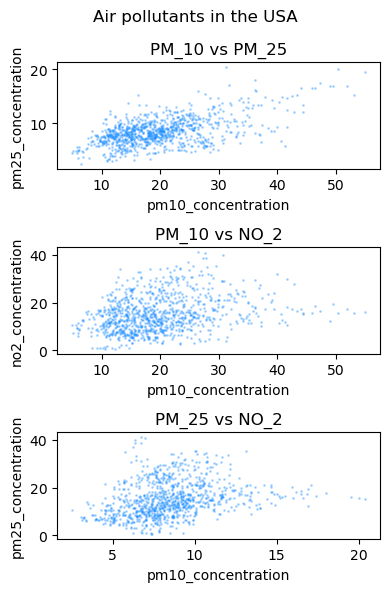

In [270]:
### ANSWER ###

size = 1
a = 0.3
col = "dodgerblue"

plt.figure(figsize=(4,6))

plt.suptitle("Air pollutants in the USA")

plt.subplot(3,1,1)
plt.scatter(airqual_USA["pm10_concentration"], airqual_USA["pm25_concentration"], s=size, alpha=a, c=col)
plt.title("PM_10 vs PM_25")
plt.xlabel("pm10_concentration")
plt.ylabel("pm25_concentration")

plt.subplot(3,1,2)
plt.scatter(airqual_USA["pm10_concentration"], airqual_USA["no2_concentration"], s=size, alpha=a, c=col)
plt.title("PM_10 vs NO_2")
plt.xlabel("pm10_concentration")
plt.ylabel("no2_concentration")

plt.subplot(3,1,3)
plt.scatter(airqual_USA["pm25_concentration"], airqual_USA["no2_concentration"], s=size, alpha=a, c=col)
plt.title("PM_25 vs NO_2")
plt.xlabel("pm10_concentration")
plt.ylabel("pm25_concentration")

plt.tight_layout()

plt.savefig("air_quality.jpg")

# -- The points are given in the text above. 
# -- Partial credit if only one of the plot has the correct characteristics.

### &#9989;&nbsp; **Task 2 (4 points):** Looking at the plots, answer the following questions

1. Which plots looks like it has the strongest correlation? Justify your answer (1 point).
2. Which plot looks the most linear? (1 point).
3. Which plot do you believe would be the easiest to create a model for? Justify your answer (1 point).
4. Do you believe your graphs in part $2.2$ correspond with your correlation figures from part $2.1$? Justify your answer. (1 points)

<font size=8 color="#009600">&#9998;</font> Put your answer here

**Part 1 (1pt):**  

**Part 2 (1pt):**  

**Part 3 (1pt):**  

**Part 4 (1pt):**

In [273]:
### ANSWER ###

# 1. 1 point, any answer as long as justified, no partial credit
# pm_10 vs pm_25 looks like a strong correlation, and supported by correlation coefficients above

# 2.  1 point, any answer as long as justified, no partial credit
# pm_10 vs pm_25 looks the most linear

# 3.  1 point, any answer as long as justified, no partial credit
# Because it is the strongest correlation and linear, probably pm_10 vs pm_25 is the easiest to model

#4. Any thoughtful answer receives full credit: 1 point
#Students must make the connection between the behavior on the correlation graphs and the figures calculated in part 2.1 
#(That is, the graphs should depict the correlation trends indicated by the correlation coefficients from part 2.1)
#No partial credit if this part is missing from answer

# Part 3: The Ukulele Detective (15 points)
You are listening to someone play ukulele and you want identify what note they are playing. Fortunately, you have your trusty data collector that can tell you the amplitude of the sound at a given time and you brought your computer to analyze the data with Python. 

Your task is to take the sine wave model for notes,

$y=A \mathrm{sin}(2\pi f t+\phi)$

and fit it to your data to find the best fit parameters for $A$, $f$, and $\phi$ using `curve_fit` and identify what frequency of note is being played using your best fit value for $f$. 

If you don't know what those parameters are, do some googling/research to find out. If you still can't figure them out, come to office hours or talk to your instructor.


### 3.1 Reading in Data and Plotting (2 points)
### &#9989;&nbsp; Task
With this homework, you will find a data file called `ukulele_data.csv`. In the cell below, load in the data and plot it with time on the x-axis and amplitude on the y-axis.

In [276]:
# Put your code here!!

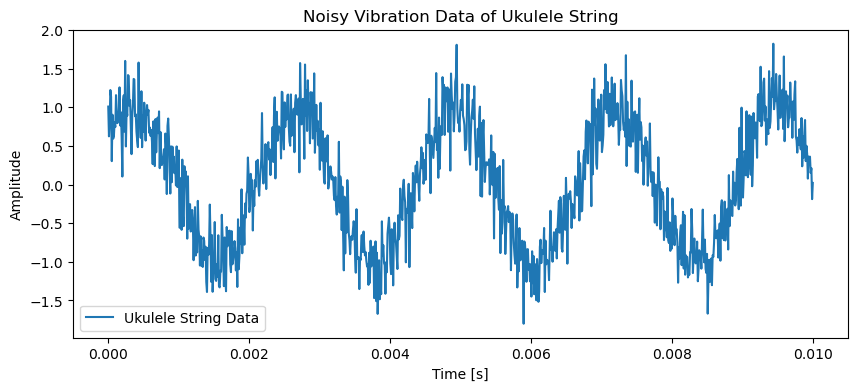

In [277]:
### ANSWER ###

import numpy as np
import matplotlib.pyplot as plt

ukulele_data = pd.read_csv('ukulele_data.csv')
ukulele_data.head()

# Plot the data
plt.figure(figsize=(10, 4))
plt.plot(ukulele_data['time(s)'], ukulele_data['Amplitude'], label='Ukulele String Data')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Noisy Vibration Data of Ukulele String')
plt.legend()
plt.show()


### RUBRIC
# 1 point for reading in the data
# 1 point for plotting the data with labels/legend (no partial points here)

## 3.2 Setting up your model for fitting (2 points)
### &#9989;&nbsp;Task
To use `curve_fit`, you need to define your model as a Python function. Create a Python function using the sine wave model from above. 

In [279]:
# Put your code here!

In [280]:
### ANSWER ###
def sine_wave(t, A, f, phi):
    return A * np.sin(2 * np.pi * f * t + phi)

### RUBRIC
# 1 point defining function with time and 3 parameters
# 1 point returning the equation (for all values of t)

## 3.3 Using `curve_fit` (5 points)
### &#9989;&nbsp; Task
Now use `curve_fit` to identify your best fit parameters and plot the data and best fit together. 

In [282]:
# put your code here!

# Initial Guess guidance
# A_guess = # A is the amplitude, so pick a value that is roughly the average of the amplitude
# f_guess = 400.0 Hz
# phi_guess = 0.0

In [283]:
### ANSWER ###
from scipy.optimize import curve_fit

# Initial parameter guesses
A_guess = (np.max(ukulele_data['Amplitude']) - np.min(ukulele_data['Amplitude'])) / 2
f_guess = 400.0  # A rough guess, starting with 400 Hz
phi_guess = 0.0

initial_guesses = [A_guess, f_guess, phi_guess]

# Perform the curve fitting
params_opt, params_cov = curve_fit(sine_wave, ukulele_data['time(s)'], ukulele_data['Amplitude'], p0=initial_guesses)

# Extract the optimized parameters
A_est, f_est, phi_est = params_opt
print(A_est, f_est, phi_est)

1.012449558383651 439.67916148801805 -5.7753039784708315


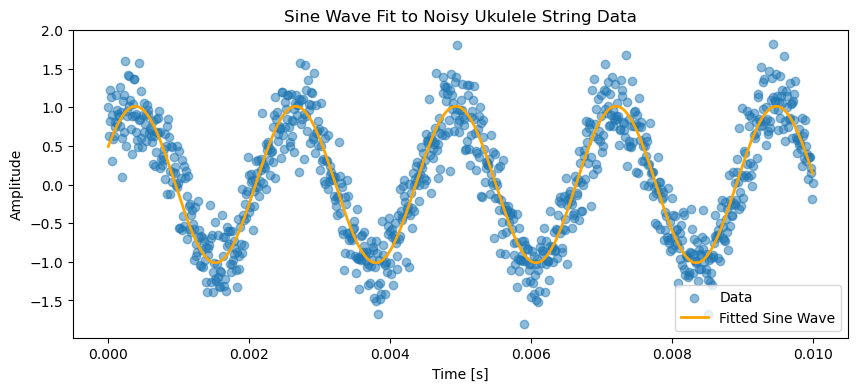

In [284]:
### ANSWER ###
# Generate fitted data
y_fit = sine_wave(ukulele_data['time(s)'], A_est, f_est, phi_est)

# Plotting
plt.figure(figsize=(10, 4))
plt.scatter(ukulele_data['time(s)'], ukulele_data['Amplitude'], label='Data',alpha=0.5)
plt.plot(ukulele_data['time(s)'], y_fit, label='Fitted Sine Wave',linewidth=2,color='orange')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Sine Wave Fit to Noisy Ukulele String Data')
plt.legend()
plt.show()

### RUBRIC
# 1 point for calling curve_fit correctly
# 1 point for unpacking parameters to generate y values (either in the y-generation or separately)
# 1 point for generating y values
# 1 point for plotting the data and the fit (no partial points here)
# 1 point for including appropriate labels/legend/title/etc. (no partial points here)

## 3.4 Making Conclusions (2 points)
### &#9989;&nbsp; Task
What note is the ukulele playing playing? Justify that this makes sense by doing some research about ukuleles!

<font size=+3>&#9998;</font> *Put your answer here.*

In [287]:
### ANSWER
# It is playing A 440 Hz - that is the highest string on a soprano or concert ukulele, 
# so it is reasonable to expect a ukulele would play that note

### RUBRIC
# 1 point for the correct note
# 1 point for reasonable justification

### 3.5 Documenting your solution pathway (5 points)
### &#9989;&nbsp; Task

**Describe in detail** how you solved the problem including any external resources you consulted (e.g. generative AI **prompts and outputs**, past assignments, Code Portfolio, Stack Overflow, Google, etc.) and how they informed your approach. You must also describe how you know your solution works (e.g. and calculations you made, tests you ran, etc.)

If you did not use external resources, describe your thought process for solving the problem by answering the following questions:
1. How did you know where to start?
2. What prior knowledge did you recall to solve the problem?
3. How do you know that your solution works?

<font size=+3>&#9998;</font> *Put your answer here.*

In [290]:
### RUBRIC
# 5 out of 5 for a detailed answer that covers prompts/outputs and how they informed approach AND how they know solution works
# 5 out of 5 for answering the 3 questions in detail if they did not use resources
# 2 out of 5 if they are missing any one item
# 0 out of 5 if they are missing more than one item

---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Homework Assignments" section, find the submission folder link for Homework #3, and upload it there.

&#169; 2024 Copyright the Department of Computational Mathematics, Science and Engineering.